# Implementation of the QRC trial and error

Loading data from file


(array([720000., 740000., 760000., 780000., 800000., 820000., 840000.,
        860000.]),
 [Text(720000.0, 0, '720000'),
  Text(740000.0, 0, '740000'),
  Text(760000.0, 0, '760000'),
  Text(780000.0, 0, '780000'),
  Text(800000.0, 0, '800000'),
  Text(820000.0, 0, '820000'),
  Text(840000.0, 0, '840000'),
  Text(860000.0, 0, '860000')])

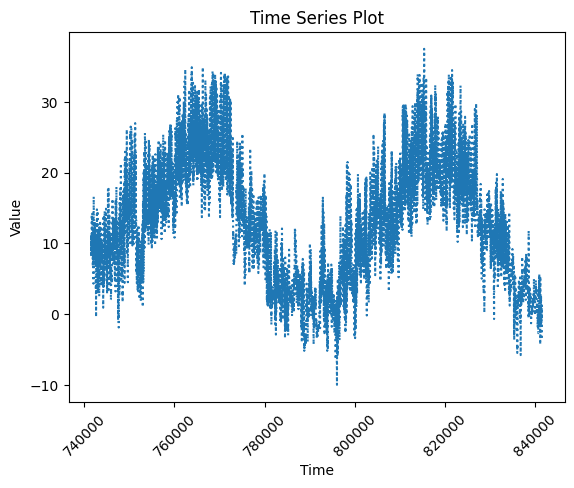

In [12]:
import numpy as np
from matplotlib import pyplot as plt
import os.path

from qreservoir.encoders import CHEEncoder
from qreservoir.models import RCModel
from qreservoir.reservoirs import CNOTReservoir
from sklearn.linear_model import LinearRegression

from src.data.loading.configs import MODEL_DIR_QRC
# ---- load data ----
from src.data.loading.geosphere import Geosphere

data = Geosphere().load_data_into_memory()

historically_relevant_data = data[-100000:]

plt.plot(historically_relevant_data.index, historically_relevant_data['tl'], linestyle = 'dotted')

# Add title and axis labels
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation=45)

In [13]:
# ---- select data ----

import pandas as pd

selected_columns = [
    'cglo'
    , 'chim'
    , 'dd'
    , 'ddx'
    , 'ff'
#    , 'ffam_flag'
    , 'ffx'
    , 'p'
#    , 'pred'
    , 'rf'
    , 'rr'
    , 'rrm'
    , 'sh'
    , 'so'
    , 'tb10'
    , 'tb20'
    , 'tb50'
    , 'tl'
    , 'tlmax'
    , 'tlmin'
    , 'ts'
    , 'tsmax'
    , 'tsmin'
    , 'zeitx'
    , 'timestamps'
#    , 'stationId'
]

usable_data = historically_relevant_data.dropna(axis="columns", how="all")

final_data_columns = usable_data.columns.intersection(selected_columns)

final_data = historically_relevant_data[final_data_columns].reset_index(drop=True)
final_data.set_index(pd.to_datetime(final_data['timestamps'], format="ISO8601"))
final_data.index.freq = '10min'
final_data.drop('timestamps', axis="columns", inplace=True)

# output
print("Selected columns: {}".format(selected_columns))
print("Usable columns: {}".format(usable_data.columns))
print("Realised columns: {}".format(final_data_columns))
print("Final data dimensions: {}".format(final_data.shape))
print(any(final_data.isna()))

Selected columns: ['cglo', 'chim', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'sh', 'so', 'tb10', 'tb20', 'tb50', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps']
Usable columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffam_flag', 'ffx', 'p', 'pred', 'rf', 'rr',
       'rrm', 'so', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx',
       'timestamps', 'stationId'],
      dtype='object')
Realised columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'so', 'tl',
       'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps'],
      dtype='object')
Final data dimensions: (100000, 17)
True


In [14]:
from qulacs import Observable
import pickle
# ---- model selection ----
import qreservoir.encoders as qe
# parameters of the time-series:
# - one-dimensional
# - value 'tl'

# author info (citation)
# Source code: XYZ

# reload/select best model
file = MODEL_DIR_QRC / "QRC_model.pkl"

import pmdarima as pa
filtered_data = final_data['tl']
train, test = pa.model_selection.train_test_split(filtered_data, test_size=0.2)
train_array, test_array = train.to_numpy().reshape(-1,1), test.to_numpy().reshape(-1,1)

# create model
my_encoder = qe.CHEEncoder(feature_num=1)
my_encoder.print_circuit()

my_reservoir = CNOTReservoir(my_encoder,
                             ancilla_num=1,
                             depth=1)
my_observables = [Observable(1) for _ in range(1)]
QRC_model = RCModel(reservoir=my_reservoir,
                    observables=my_observables,
                    subestimator=LinearRegression())

QRC_model.fit(train_array)



   ___   
  |RX |  
--|   |--
  |___|  


[[13.47517594]
 [13.47517594]
 [13.47517594]
 ...
 [13.47517594]
 [13.47517594]
 [13.47517594]]
Mean error: 7.218233603607546
Standard deviation: 8.623920163068243
Mean error: 6.9621976026575325
Standard deviation: 7.7127060021742695


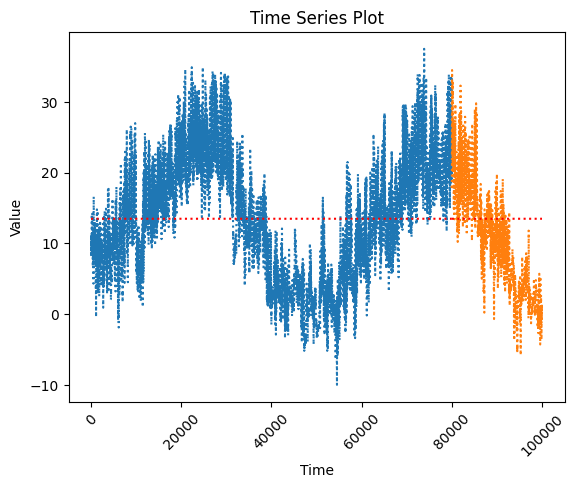

In [15]:
# evaluate model
plt.plot(train.index, train, linestyle = 'dotted')

# --------------------------------------------------------------------------------------
# visual assessment of goodness of fit
# in-sample prediction
QRC_model_in_sample_prediction = QRC_model.predict(train_array, additional_samples=0)
print(QRC_model_in_sample_prediction)
plt.plot(train.index, QRC_model_in_sample_prediction, linestyle = 'dotted', color='red')

# Add title and axis labels
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation=45)

# -> very crude estimate!
# --------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------
# calculate average prediction error of in-sample-predictions (make this a little more technical)
mean_error = np.mean(np.fabs(np.subtract(QRC_model_in_sample_prediction, train_array)))
print("Mean error: {}".format(mean_error))

std_error = np.std(np.subtract(QRC_model_in_sample_prediction, train_array))
print("Standard deviation: {}".format(std_error))
# --------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------
# calculate average prediction of out-of-sample-predictions - visual and technical
plt.plot(test.index, test, linestyle = 'dotted')
oos_predictions = QRC_model.predict(test_array, additional_samples=0)
plt.plot(test.index, oos_predictions, linestyle = 'dotted', color='red')

mean_error = np.mean(np.fabs(np.subtract(oos_predictions, test_array)))
print("Mean error: {}".format(mean_error))

std_error = np.std(np.subtract(oos_predictions, test_array))
print("Standard deviation: {}".format(std_error))